# Atividade prática — Análise de Dados de Energia

**Disciplina:** Soluções em Energias Renováveis e Sustentáveis

**Integrantes:**

- Lucas Angelo — RM569530
- Gustavo Guedes — RM569779
- Gabriel Rodrigues — RM569322
- Gustavo de Souza — RM570746
- Anthur Tae Gun — RM570647

Este notebook reúne as etapas de inspeção, preparação, filtragem, visualização e interpretação dos seis datasets da atividade.

## Bibliotecas utilizadas

O Pandas será utilizado para manipulação dos dados e o Matplotlib para os gráficos.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import re
import unicodedata
from IPython.display import display

try:
    plt.style.use('seaborn-v0_8-whitegrid')
except OSError:
    plt.style.use('ggplot')

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda valor: f'{valor:.2f}')

# Dataset 1 — Appliances Energy Prediction (UCI)

## Situação

Uma empresa de eficiência energética deseja identificar períodos de consumo elevado dos eletrodomésticos e verificar quais condições de temperatura estavam presentes nesses momentos.

## Etapa A — Orange Data Mining

Fluxo utilizado no Orange: carregamento dos dados, inspeção no Data Table, seleção de `Appliances`, `lights`, três temperaturas e três umidades, verificação de ausentes, geração de amostra aleatória de 10% e exportação em CSV.

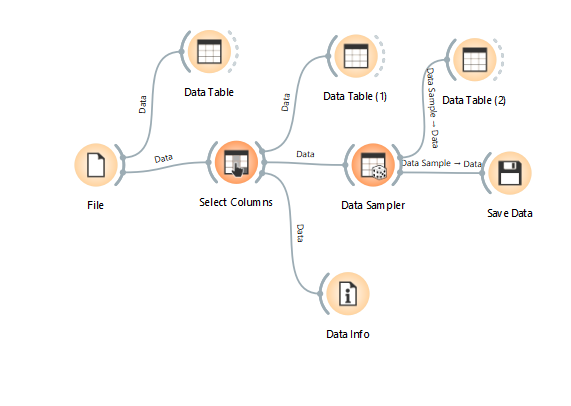

## Etapa B — Python e Pandas

### 1. Carregamento e seleção das colunas

O caminho original foi preservado. Depois do carregamento, são mantidas apenas as colunas solicitadas no exercício.

In [ ]:
df1 = pd.read_csv('/content/energydata_complete.csv')

colunas_df1 = ['Appliances', 'lights', 'T1', 'RH_1', 'T2', 'RH_2', 'T3', 'RH_3']
df1 = df1[colunas_df1].copy()

display(df1.head())

,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3
0,40,0,20.89,35.40,17.76,39.16,20.29,36.90
1,90,10,21.89,53.10,21.29,45.36,21.63,49.23
2,50,0,21.39,35.50,17.63,40.53,21.67,35.20
3,50,0,21.39,41.03,23.89,34.84,22.03,36.93
4,70,0,19.96,35.13,16.46,40.13,20.00,36.40


### 2. Inspeção inicial

São apresentados o formato, a estrutura, as estatísticas descritivas e a quantidade de valores ausentes.

In [ ]:
print(f'Quantidade de linhas: {df1.shape[0]}')
print(f'Quantidade de colunas: {df1.shape[1]}')
print('\nEstrutura do DataFrame:')
df1.info()

print('\nEstatísticas descritivas:')
display(df1.describe().T)

print('\nValores ausentes por coluna:')
display(df1.isnull().sum().to_frame('Valores ausentes'))

Quantidade de linhas: 1974
Quantidade de colunas: 8

Estrutura do DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1974 entries, 0 to 1973
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Appliances  1974 non-null   int64  
 1   lights      1974 non-null   int64  
 2   T1          1974 non-null   float64
 3   RH_1        1974 non-null   float64
 4   T2          1974 non-null   float64
 5   RH_2        1974 non-null   float64
 6   T3          1974 non-null   float64
 7   RH_3        1974 non-null   float64
dtypes: float64(6), int64(2)
memory usage: 123.5 KB

Estatísticas descritivas:


,count,mean,std,min,25%,50%,75%,max
Appliances,1974.00,93.04,93.83,20.00,50.00,60.00,100.00,770.00
lights,1974.00,3.84,7.94,0.00,0.00,0.00,0.00,50.00
T1,1974.00,21.66,1.57,16.79,20.70,21.60,22.60,26.26
RH_1,1974.00,40.22,3.97,27.73,37.21,39.59,42.99,57.50
T2,1974.00,20.29,2.13,16.10,18.79,20.00,21.50,28.92
RH_2,1974.00,40.41,4.04,24.06,37.76,40.43,43.23,56.03
T3,1974.00,22.23,1.96,17.20,20.70,22.10,23.29,29.20
RH_3,1974.00,39.21,3.29,30.13,36.90,38.43,41.74,49.23



Valores ausentes por coluna:


,Valores ausentes
Appliances,0
lights,0
T1,0
RH_1,0
T2,0
RH_2,0
T3,0
RH_3,0


### 3. Renomeação das colunas

`Appliances` recebe um nome mais claro e três atributos ambientais são simplificados.

In [ ]:
df1.rename(columns={
    'Appliances': 'Consumo_Eletrodomesticos',
    'T1': 'Temperatura_1',
    'T2': 'Temperatura_2',
    'T3': 'Temperatura_3'
}, inplace=True)

display(df1.head())

,Consumo_Eletrodomesticos,lights,Temperatura_1,RH_1,Temperatura_2,RH_2,Temperatura_3,RH_3
0,40,0,20.89,35.40,17.76,39.16,20.29,36.90
1,90,10,21.89,53.10,21.29,45.36,21.63,49.23
2,50,0,21.39,35.50,17.63,40.53,21.67,35.20
3,50,0,21.39,41.03,23.89,34.84,22.03,36.93
4,70,0,19.96,35.13,16.46,40.13,20.00,36.40


### 4. Consumo acima de 70% do valor máximo

O limiar é calculado a partir do maior consumo registrado na amostra.

In [ ]:
maximo_df1 = df1['Consumo_Eletrodomesticos'].max()
limiar_df1 = maximo_df1 * 0.70
alto_consumo_df1 = df1[df1['Consumo_Eletrodomesticos'] > limiar_df1].copy()

quantidade_alto_df1 = len(alto_consumo_df1)
percentual_alto_df1 = quantidade_alto_df1 / len(df1) * 100

print(f'Maior consumo registrado: {maximo_df1:.2f} Wh')
print(f'Limiar de 70%: {limiar_df1:.2f} Wh')
print(f'Registros acima do limiar: {quantidade_alto_df1}')
print(f'Percentual da amostra: {percentual_alto_df1:.2f}%')

display(alto_consumo_df1.head(10))

Maior consumo registrado: 770.00 Wh
Limiar de 70%: 539.00 Wh
Registros acima do limiar: 22
Percentual da amostra: 1.11%


,Consumo_Eletrodomesticos,lights,Temperatura_1,RH_1,Temperatura_2,RH_2,Temperatura_3,RH_3
352,620,0,24.39,44.33,25.37,37.74,26.73,38.86
427,650,0,20.89,36.70,18.29,39.66,21.20,36.00
453,560,30,21.36,36.09,19.57,37.16,21.63,35.03
616,570,10,24.89,32.67,23.56,31.14,23.60,30.82
696,590,30,19.86,47.66,18.70,34.10,18.43,37.83
744,740,20,19.50,42.13,18.26,39.20,19.89,39.19
916,750,30,22.43,43.00,21.93,40.13,21.23,42.60
993,690,10,22.53,45.03,22.07,39.79,22.39,41.93
1026,560,0,21.00,38.90,19.29,40.20,21.70,37.20
1173,580,0,21.60,34.63,19.50,33.76,22.57,34.87


### 5. Inclusão da temperatura como segundo critério

O segundo DataFrame mantém simultaneamente consumo elevado e temperatura de T1 acima da média.

In [ ]:
temperatura_media_df1 = df1['Temperatura_1'].mean()
alto_consumo_temperatura_df1 = alto_consumo_df1[
    alto_consumo_df1['Temperatura_1'] > temperatura_media_df1
].copy()

quantidade_duplo_df1 = len(alto_consumo_temperatura_df1)
removidos_df1 = quantidade_alto_df1 - quantidade_duplo_df1
reducao_df1 = removidos_df1 / quantidade_alto_df1 * 100 if quantidade_alto_df1 else 0

print(f'Temperatura média de T1: {temperatura_media_df1:.2f} °C')
print(f'Somente consumo elevado: {quantidade_alto_df1}')
print(f'Consumo elevado e temperatura acima da média: {quantidade_duplo_df1}')
print(f'Registros removidos pelo segundo critério: {removidos_df1}')
print(f'Redução relativa: {reducao_df1:.2f}%')
print(f'Interpretação: a condição de temperatura reduziu o conjunto de {quantidade_alto_df1} para {quantidade_duplo_df1} registros, tornando o recorte mais específico.')

display(alto_consumo_temperatura_df1.head(10))

Temperatura média de T1: 21.66 °C
Somente consumo elevado: 22
Consumo elevado e temperatura acima da média: 8
Registros removidos pelo segundo critério: 14
Redução relativa: 63.64%
Interpretação: a condição de temperatura reduziu o conjunto de 22 para 8 registros, tornando o recorte mais específico.


,Consumo_Eletrodomesticos,lights,Temperatura_1,RH_1,Temperatura_2,RH_2,Temperatura_3,RH_3
352,620,0,24.39,44.33,25.37,37.74,26.73,38.86
616,570,10,24.89,32.67,23.56,31.14,23.60,30.82
916,750,30,22.43,43.00,21.93,40.13,21.23,42.60
993,690,10,22.53,45.03,22.07,39.79,22.39,41.93
1182,600,20,24.89,48.13,28.92,37.95,27.10,42.44
1196,580,0,23.63,47.23,24.81,43.47,26.17,40.50
1835,720,10,22.20,37.93,21.10,37.00,23.17,36.63
1964,620,0,22.70,41.72,22.43,39.00,23.29,39.20


### 6. Gráfico comparativo

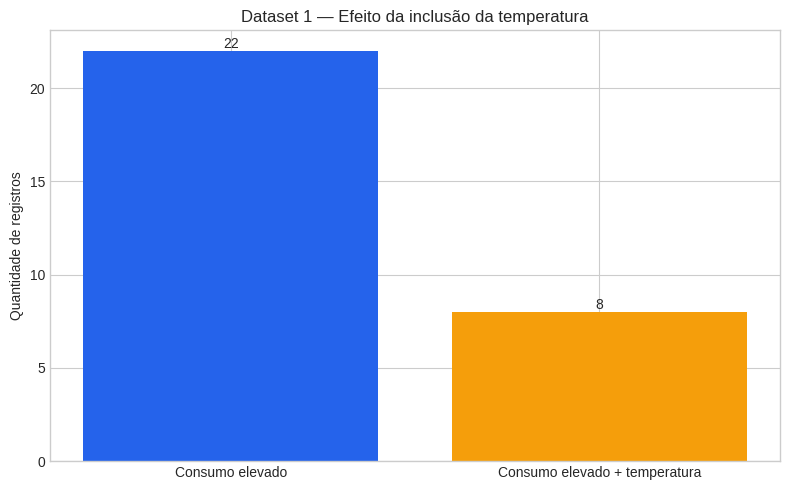

In [ ]:
categorias_df1 = ['Consumo elevado', 'Consumo elevado + temperatura']
valores_df1 = [quantidade_alto_df1, quantidade_duplo_df1]

plt.figure(figsize=(8, 5))
plt.bar(categorias_df1, valores_df1, color=['#2563EB', '#F59E0B'])
plt.title('Dataset 1 — Efeito da inclusão da temperatura')
plt.ylabel('Quantidade de registros')
for indice, valor in enumerate(valores_df1):
    plt.text(indice, valor, str(valor), ha='center', va='bottom')
plt.tight_layout()
plt.show()

# Dataset 2 — Steel Industry Energy Consumption (UCI)

## Situação

A equipe de gestão de energia de uma indústria siderúrgica deseja localizar situações de consumo elevado e verificar se esses períodos coincidem com carga máxima ou fator de potência mais baixo.

## Etapa A — Orange Data Mining

No Orange devem ser mantidos `Usage_kWh`, os atributos de potência reativa, os fatores de potência, `WeekStatus`, `Day_of_week` e `Load_Type`. A amostra exportada deve corresponder a 20% dos registros.

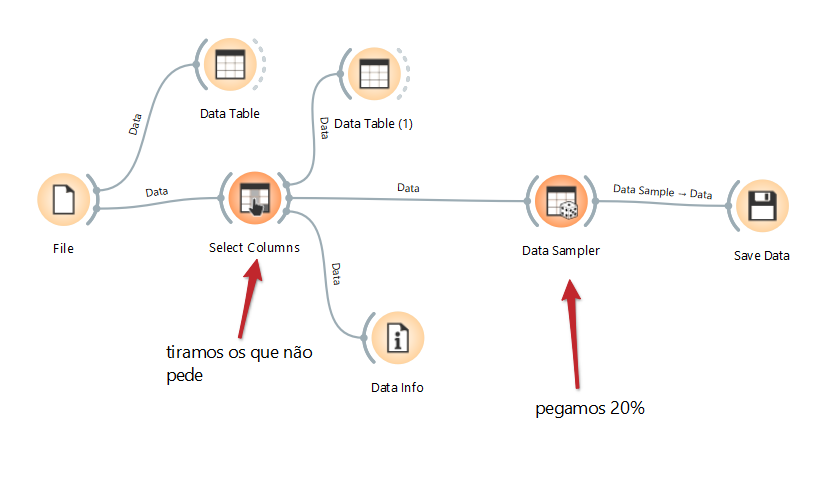

## Etapa B — Python e Pandas

### 1. Carregamento, seleção e renomeação

In [ ]:
df2 = pd.read_csv('/content/Steel_industry_data.csv')

colunas_reativas_df2 = [coluna for coluna in df2.columns if 'Reactive' in coluna]
colunas_fixas_df2 = [
    'Usage_kWh',
    'Lagging_Current_Power_Factor',
    'Leading_Current_Power_Factor',
    'WeekStatus',
    'Day_of_week',
    'Load_Type'
]
colunas_df2 = [coluna for coluna in colunas_fixas_df2 + colunas_reativas_df2 if coluna in df2.columns]
df2 = df2[colunas_df2].copy()

df2.rename(columns={
    'Usage_kWh': 'Consumo_kWh',
    'Lagging_Current_Power_Factor': 'Fator_Potencia_Atrasado',
    'Leading_Current_Power_Factor': 'Fator_Potencia_Adiantado'
}, inplace=True)

display(df2.head())

,Consumo_kWh,Fator_Potencia_Atrasado,Fator_Potencia_Adiantado,WeekStatus,Day_of_week,Load_Type,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh
0,2.88,60.20,100.00,Weekend,Sunday,Light_Load,3.82,0.00
1,60.77,78.46,100.00,Weekday,Thursday,Maximum_Load,48.02,0.00
2,120.42,89.61,100.00,Weekday,Friday,Maximum_Load,59.65,0.00
3,3.13,100.00,18.53,Weekend,Saturday,Light_Load,0.00,16.60
4,58.86,94.19,100.00,Weekday,Friday,Medium_Load,20.99,0.00


### 2. Inspeção inicial

In [ ]:
print(f'Quantidade de linhas: {df2.shape[0]}')
print(f'Quantidade de colunas: {df2.shape[1]}')
print('\nEstrutura do DataFrame:')
df2.info()

print('\nEstatísticas descritivas:')
display(df2.describe(include='all').T)

print('\nValores ausentes por coluna:')
display(df2.isnull().sum().to_frame('Valores ausentes'))

print('\nCategorias de Load_Type:')
print(df2['Load_Type'].value_counts())

print('\nCategorias de WeekStatus:')
print(df2['WeekStatus'].value_counts())

Quantidade de linhas: 7008
Quantidade de colunas: 8

Estrutura do DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7008 entries, 0 to 7007
Data columns (total 8 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Consumo_kWh                           7008 non-null   float64
 1   Fator_Potencia_Atrasado               7008 non-null   float64
 2   Fator_Potencia_Adiantado              7008 non-null   float64
 3   WeekStatus                            7008 non-null   object 
 4   Day_of_week                           7008 non-null   object 
 5   Load_Type                             7008 non-null   object 
 6   Lagging_Current_Reactive.Power_kVarh  7008 non-null   float64
 7   Leading_Current_Reactive_Power_kVarh  7008 non-null   float64
dtypes: float64(5), object(3)
memory usage: 438.1+ KB

Estatísticas descritivas:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Consumo_kWh,7008.00,NaN,NaN,NaN,27.79,33.72,2.45,3.20,4.57,52.11,153.14
Fator_Potencia_Atrasado,7008.00,NaN,NaN,NaN,80.67,18.87,37.87,63.60,87.99,98.84,100.00
Fator_Potencia_Adiantado,7008.00,NaN,NaN,NaN,84.49,30.31,12.71,99.71,100.00,100.00,100.00
WeekStatus,7008,2,Weekday,5026,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Day_of_week,7008,7,Thursday,1048,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Load_Type,7008,3,Light_Load,3572,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Lagging_Current_Reactive.Power_kVarh,7008.00,NaN,NaN,NaN,13.21,16.44,0.00,2.38,5.04,22.98,87.70
Leading_Current_Reactive_Power_kVarh,7008.00,NaN,NaN,NaN,3.80,7.36,0.00,0.00,0.00,1.86,27.65



Valores ausentes por coluna:


,Valores ausentes
Consumo_kWh,0
Fator_Potencia_Atrasado,0
Fator_Potencia_Adiantado,0
WeekStatus,0
Day_of_week,0
Load_Type,0
Lagging_Current_Reactive.Power_kVarh,0
Leading_Current_Reactive_Power_kVarh,0



Categorias de Load_Type:
Load_Type
Light_Load      3572
Medium_Load     1937
Maximum_Load    1499
Name: count, dtype: int64

Categorias de WeekStatus:
WeekStatus
Weekday    5026
Weekend    1982
Name: count, dtype: int64


### 3. Consumo acima de 75% do máximo

In [ ]:
maximo_df2 = df2['Consumo_kWh'].max()
limiar_df2 = maximo_df2 * 0.75
alto_consumo_df2 = df2[df2['Consumo_kWh'] > limiar_df2].copy()

quantidade_alto_df2 = len(alto_consumo_df2)
percentual_alto_df2 = quantidade_alto_df2 / len(df2) * 100

print(f'Maior consumo registrado: {maximo_df2:.2f} kWh')
print(f'Limiar de 75%: {limiar_df2:.2f} kWh')
print(f'Registros acima do limiar: {quantidade_alto_df2}')
print(f'Percentual da amostra: {percentual_alto_df2:.2f}%')

display(alto_consumo_df2.head(10))

Maior consumo registrado: 153.14 kWh
Limiar de 75%: 114.85 kWh
Registros acima do limiar: 129
Percentual da amostra: 1.84%


,Consumo_kWh,Fator_Potencia_Atrasado,Fator_Potencia_Adiantado,WeekStatus,Day_of_week,Load_Type,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh
2,120.42,89.61,100.00,Weekday,Friday,Maximum_Load,59.65,0.00
62,118.22,90.95,100.00,Weekday,Thursday,Medium_Load,54.04,0.00
100,129.13,94.07,100.00,Weekday,Monday,Medium_Load,46.58,0.00
108,117.07,92.95,100.00,Weekday,Monday,Medium_Load,46.44,0.00
159,139.57,92.13,100.00,Weekday,Thursday,Maximum_Load,58.90,0.00
208,125.10,92.80,100.00,Weekday,Thursday,Maximum_Load,50.22,0.00
295,129.85,89.74,100.00,Weekday,Friday,Maximum_Load,63.86,0.00
342,140.04,91.14,100.00,Weekday,Tuesday,Maximum_Load,63.25,0.00
399,122.94,87.13,100.00,Weekday,Tuesday,Maximum_Load,69.26,0.00
531,146.88,90.16,100.00,Weekday,Monday,Maximum_Load,70.49,0.00


### 4. Registros pertencentes à categoria Maximum Load

In [ ]:
tipo_carga_normalizado_df2 = (
    alto_consumo_df2['Load_Type']
    .astype(str)
    .str.replace('_', ' ', regex=False)
    .str.strip()
)

maximum_load_df2 = tipo_carga_normalizado_df2.eq('Maximum Load').sum()
percentual_maximum_df2 = maximum_load_df2 / quantidade_alto_df2 * 100 if quantidade_alto_df2 else 0

print(f'Registros de consumo elevado classificados como Maximum Load: {maximum_load_df2}')
print(f'Percentual dentro do recorte de consumo elevado: {percentual_maximum_df2:.2f}%')

Registros de consumo elevado classificados como Maximum Load: 62
Percentual dentro do recorte de consumo elevado: 48.06%


### 5. Consumo elevado e fator de potência mais baixo

Foi adotado o limite de 90 para o fator de potência atrasado. Valores abaixo desse limite representam uma condição menos favorável e justificam uma análise mais detalhada.

In [ ]:
display(df2['Fator_Potencia_Atrasado'].describe().to_frame('Fator de potência atrasado'))

limite_fator_df2 = 90
atencao_df2 = alto_consumo_df2[
    alto_consumo_df2['Fator_Potencia_Atrasado'] < limite_fator_df2
].copy()

quantidade_atencao_df2 = len(atencao_df2)
percentual_atencao_df2 = quantidade_atencao_df2 / quantidade_alto_df2 * 100 if quantidade_alto_df2 else 0

print(f'Limite escolhido para o fator de potência: {limite_fator_df2}')
print(f'Registros com consumo elevado e fator abaixo do limite: {quantidade_atencao_df2}')
print(f'Percentual dentro do consumo elevado: {percentual_atencao_df2:.2f}%')
print('Interpretação: esses registros combinam demanda elevada com fator de potência menos favorável, condição que pode aumentar perdas e exigir maior atenção da equipe de energia.')

display(atencao_df2.head(10))

,Fator de potência atrasado
count,7008.00
mean,80.67
std,18.87
min,37.87
25%,63.60
50%,87.99
75%,98.84
max,100.00


Limite escolhido para o fator de potência: 90
Registros com consumo elevado e fator abaixo do limite: 42
Percentual dentro do consumo elevado: 32.56%
Interpretação: esses registros combinam demanda elevada com fator de potência menos favorável, condição que pode aumentar perdas e exigir maior atenção da equipe de energia.


,Consumo_kWh,Fator_Potencia_Atrasado,Fator_Potencia_Adiantado,WeekStatus,Day_of_week,Load_Type,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh
2,120.42,89.61,100.00,Weekday,Friday,Maximum_Load,59.65,0.00
295,129.85,89.74,100.00,Weekday,Friday,Maximum_Load,63.86,0.00
399,122.94,87.13,100.00,Weekday,Tuesday,Maximum_Load,69.26,0.00
605,134.60,89.72,100.00,Weekday,Monday,Maximum_Load,66.24,0.00
771,132.30,88.37,100.00,Weekend,Saturday,Medium_Load,70.06,0.00
935,116.60,89.99,100.00,Weekday,Thursday,Medium_Load,56.52,0.00
977,118.66,86.36,100.00,Weekday,Friday,Light_Load,69.26,0.00
1058,117.40,88.32,100.00,Weekday,Tuesday,Maximum_Load,62.35,0.00
1084,115.24,88.50,100.00,Weekday,Thursday,Maximum_Load,60.62,0.00
1090,122.76,89.41,100.00,Weekday,Wednesday,Maximum_Load,61.49,0.00


### 6. Gráfico comparativo

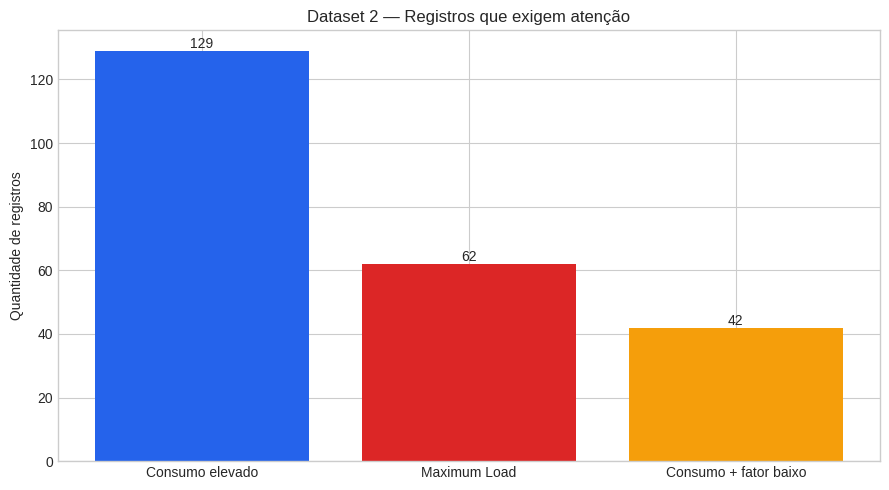

In [ ]:
categorias_df2 = ['Consumo elevado', 'Maximum Load', 'Consumo + fator baixo']
valores_df2 = [quantidade_alto_df2, maximum_load_df2, quantidade_atencao_df2]

plt.figure(figsize=(9, 5))
plt.bar(categorias_df2, valores_df2, color=['#2563EB', '#DC2626', '#F59E0B'])
plt.title('Dataset 2 — Registros que exigem atenção')
plt.ylabel('Quantidade de registros')
for indice, valor in enumerate(valores_df2):
    plt.text(indice, valor, str(valor), ha='center', va='bottom')
plt.tight_layout()
plt.show()

# Dataset 3 — Power Consumption of Tetouan City (UCI)

## Situação

A equipe de distribuição de energia deseja identificar qual zona apresenta o maior pico de consumo e verificar as condições de temperatura nos momentos de maior demanda.

## Etapa A — Orange Data Mining

No Orange devem ser mantidas as três variáveis de consumo, `Temperature`, `Humidity` e `Wind Speed`. A amostra exportada deve conter 15% dos registros.

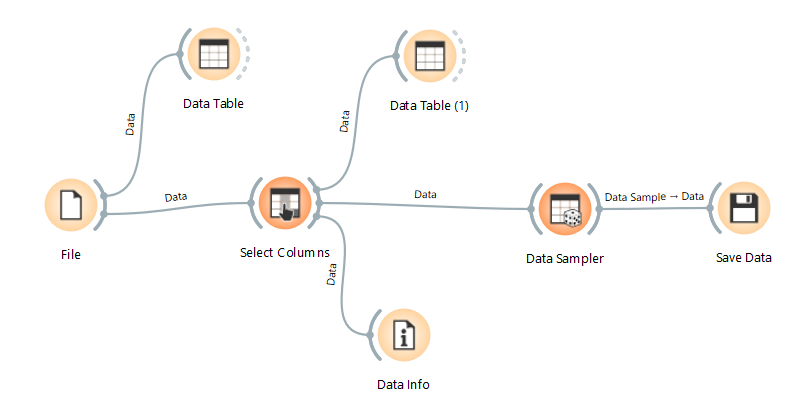

## Etapa B — Python e Pandas

### 1. Carregamento, padronização e renomeação

In [ ]:
df3 = pd.read_csv('/content/Tetuan City power consumption.csv')

df3.columns = df3.columns.str.strip().str.replace(r'\s+', ' ', regex=True)

df3.rename(columns={
    'Zone 1 Power Consumption': 'Consumo_Zona_1',
    'Zone 2 Power Consumption': 'Consumo_Zona_2',
    'Zone 3 Power Consumption': 'Consumo_Zona_3'
}, inplace=True)

colunas_df3 = [
    'Temperature',
    'Humidity',
    'Wind Speed',
    'Consumo_Zona_1',
    'Consumo_Zona_2',
    'Consumo_Zona_3'
]
df3 = df3[colunas_df3].copy()

# Convert relevant columns to numeric, coercing errors
for col in ['Temperature', 'Humidity', 'Wind Speed', 'Consumo_Zona_1', 'Consumo_Zona_2', 'Consumo_Zona_3']:
    # Strip whitespace before converting to numeric for robustness
    df3[col] = df3[col].astype(str).str.strip()
    df3[col] = pd.to_numeric(df3[col], errors='coerce')

# Drop rows where these critical columns are NaN (e.g., from 'continuous' entries or actual missing values)
df3.dropna(subset=['Temperature', 'Humidity', 'Wind Speed', 'Consumo_Zona_1', 'Consumo_Zona_2', 'Consumo_Zona_3'], inplace=True)
df3.reset_index(drop=True, inplace=True)

display(df3.head())
print('\nEstrutura do DataFrame após limpeza e conversão:')
df3.info()

,Temperature,Humidity,Wind Speed,Consumo_Zona_1,Consumo_Zona_2,Consumo_Zona_3
0,22.76,29.73,0.09,32985.15,19396.70,17623.30
1,15.92,54.44,0.09,34737.64,29803.00,14417.30
2,15.08,57.23,0.08,27894.68,20808.50,16458.80
3,12.42,72.30,0.08,42476.94,23634.10,25089.70
4,14.58,80.60,0.08,21341.14,12006.10,11531.60



Estrutura do DataFrame após limpeza e conversão:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7863 entries, 0 to 7862
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Temperature     7863 non-null   float64
 1   Humidity        7863 non-null   float64
 2   Wind Speed      7863 non-null   float64
 3   Consumo_Zona_1  7863 non-null   float64
 4   Consumo_Zona_2  7863 non-null   float64
 5   Consumo_Zona_3  7863 non-null   float64
dtypes: float64(6)
memory usage: 368.7 KB


### 2. Inspeção inicial

In [ ]:
print(f'Quantidade de linhas: {df3.shape[0]}')
print(f'Quantidade de colunas: {df3.shape[1]}')
print('\nEstrutura do DataFrame:')
df3.info()

print('\nEstatísticas descritivas:')
display(df3.describe().T)

print('\nValores ausentes por coluna:')
display(df3.isnull().sum().to_frame('Valores ausentes'))

Quantidade de linhas: 7865
Quantidade de colunas: 6

Estrutura do DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7865 entries, 0 to 7864
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Temperature     7864 non-null   object
 1   Humidity        7864 non-null   object
 2   Wind Speed      7864 non-null   object
 3   Consumo_Zona_1  7864 non-null   object
 4   Consumo_Zona_2  7864 non-null   object
 5   Consumo_Zona_3  7864 non-null   object
dtypes: object(6)
memory usage: 368.8+ KB

Estatísticas descritivas:


,count,unique,top,freq
Temperature,7864,2350,16.240,12
Humidity,7864,2455,87.20,37
Wind Speed,7864,247,0.082,343
Consumo_Zona_1,7864,6972,25920.00000,5
Consumo_Zona_2,7864,6999,17996.3,4
Consumo_Zona_3,7864,6526,9444.42,6



Valores ausentes por coluna:


,Valores ausentes
Temperature,1
Humidity,1
Wind Speed,1
Consumo_Zona_1,1
Consumo_Zona_2,1
Consumo_Zona_3,1


### 3. Consumo máximo de cada zona e identificação do maior pico

In [ ]:
colunas_zonas_df3 = ['Consumo_Zona_1', 'Consumo_Zona_2', 'Consumo_Zona_3']
maximos_df3 = df3[colunas_zonas_df3].max()
zona_maior_df3 = maximos_df3.idxmax()
maior_pico_df3 = maximos_df3.max()
limiar_df3 = maior_pico_df3 * 0.70

print('Consumo máximo de cada zona:')
display(maximos_df3.to_frame('Consumo máximo'))
print(f'Zona com o maior pico: {zona_maior_df3}')
print(f'Maior pico registrado: {maior_pico_df3:.2f}')
print(f'Limiar de 70% do maior pico: {limiar_df3:.2f}')

Consumo máximo de cada zona:


,Consumo máximo
Consumo_Zona_1,51571.50
Consumo_Zona_2,36437.20
Consumo_Zona_3,47441.70


Zona com o maior pico: Consumo_Zona_1
Maior pico registrado: 51571.50
Limiar de 70% do maior pico: 36100.05


### 4. Registros acima do limiar da zona de maior pico

In [ ]:
alto_consumo_df3 = df3[df3[zona_maior_df3] > limiar_df3].copy()

quantidade_alto_df3 = len(alto_consumo_df3)
percentual_alto_df3 = quantidade_alto_df3 / len(df3) * 100

print(f'Registros acima do limiar: {quantidade_alto_df3}')
print(f'Percentual da amostra: {percentual_alto_df3:.2f}%')
display(alto_consumo_df3.head(10))

Registros acima do limiar: 2388
Percentual da amostra: 30.37%


,Temperature,Humidity,Wind Speed,Consumo_Zona_1,Consumo_Zona_2,Consumo_Zona_3
3,12.42,72.30,0.08,42476.94,23634.10,25089.70
8,14.66,65.92,0.07,37286.69,30716.20,15834.80
12,21.03,86.50,0.07,40993.91,25383.40,24960.00
14,27.06,47.58,4.91,37475.16,24276.20,25140.60
19,19.20,65.81,4.92,40676.03,24754.70,25095.90
21,27.11,43.35,4.91,40256.07,27416.30,25453.50
22,16.66,67.21,4.92,43334.81,25452.40,25368.40
25,26.92,70.20,4.91,36511.89,25906.30,25654.90
28,16.32,53.54,4.92,40137.72,23463.80,24659.30
30,15.90,62.58,0.08,36605.32,29736.70,16595.40


### 5. Inclusão da temperatura como condição ambiental

In [ ]:
temperatura_media_df3 = df3['Temperature'].mean()
alto_consumo_temperatura_df3 = alto_consumo_df3[
    alto_consumo_df3['Temperature'] > temperatura_media_df3
].copy()

quantidade_duplo_df3 = len(alto_consumo_temperatura_df3)
removidos_df3 = quantidade_alto_df3 - quantidade_duplo_df3
reducao_df3 = removidos_df3 / quantidade_alto_df3 * 100 if quantidade_alto_df3 else 0

print(f'Temperatura média: {temperatura_media_df3:.2f} °C')
print(f'Somente consumo elevado: {quantidade_alto_df3}')
print(f'Consumo elevado e temperatura acima da média: {quantidade_duplo_df3}')
print(f'Registros removidos: {removidos_df3}')
print(f'Redução relativa: {reducao_df3:.2f}%')
print(f'Interpretação: a condição ambiental reduziu o recorte de {quantidade_alto_df3} para {quantidade_duplo_df3} registros.')

display(alto_consumo_temperatura_df3.head(10))

Temperatura média: 18.79 °C
Somente consumo elevado: 2388
Consumo elevado e temperatura acima da média: 1597
Registros removidos: 791
Redução relativa: 33.12%
Interpretação: a condição ambiental reduziu o recorte de 2388 para 1597 registros.


,Temperature,Humidity,Wind Speed,Consumo_Zona_1,Consumo_Zona_2,Consumo_Zona_3
12,21.03,86.50,0.07,40993.91,25383.40,24960.00
14,27.06,47.58,4.91,37475.16,24276.20,25140.60
19,19.20,65.81,4.92,40676.03,24754.70,25095.90
21,27.11,43.35,4.91,40256.07,27416.30,25453.50
25,26.92,70.20,4.91,36511.89,25906.30,25654.90
40,26.64,53.55,4.91,37782.02,24569.00,22877.50
50,19.60,67.65,0.07,38153.85,31805.00,20483.90
52,22.79,62.78,0.07,48349.48,32449.40,35757.70
54,26.60,73.10,4.91,36369.19,25496.50,22721.00
59,20.32,64.15,0.08,42875.76,25286.10,27323.10


### 6. Gráficos comparativos

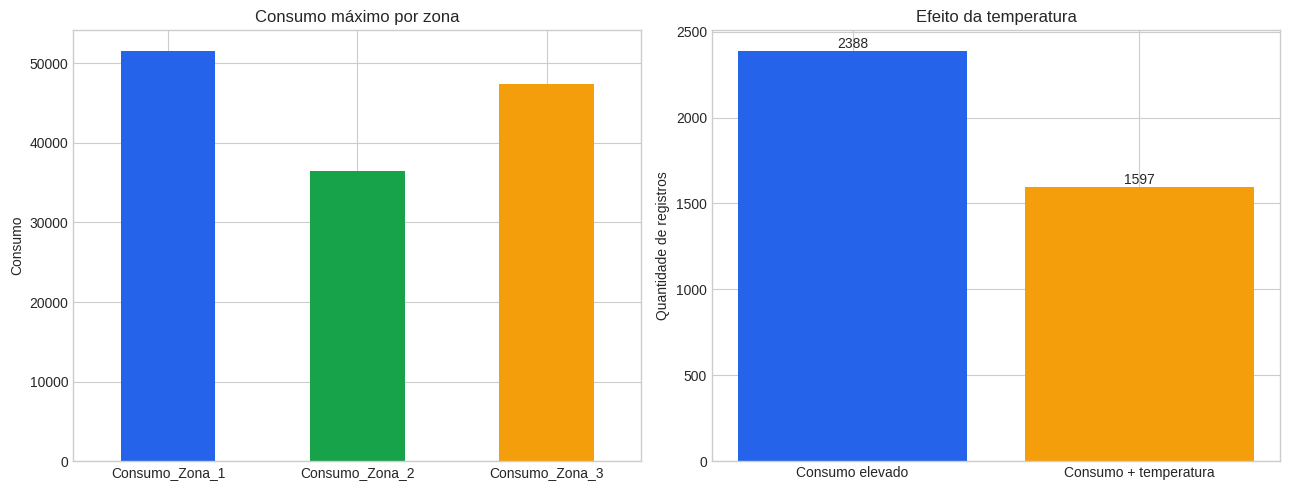

In [ ]:
figura_df3, eixos_df3 = plt.subplots(1, 2, figsize=(13, 5))

maximos_df3.plot(kind='bar', ax=eixos_df3[0], color=['#2563EB', '#16A34A', '#F59E0B'])
eixos_df3[0].set_title('Consumo máximo por zona')
eixos_df3[0].set_ylabel('Consumo')
eixos_df3[0].tick_params(axis='x', rotation=0)

categorias_df3 = ['Consumo elevado', 'Consumo + temperatura']
valores_df3 = [quantidade_alto_df3, quantidade_duplo_df3]
eixos_df3[1].bar(categorias_df3, valores_df3, color=['#2563EB', '#F59E0B'])
eixos_df3[1].set_title('Efeito da temperatura')
eixos_df3[1].set_ylabel('Quantidade de registros')
for indice, valor in enumerate(valores_df3):
    eixos_df3[1].text(indice, valor, str(valor), ha='center', va='bottom')

plt.tight_layout()
plt.show()

# Dataset 4 — Solar Power Generation Data (Kaggle)

## Situação

A equipe de operação de uma usina fotovoltaica deseja localizar períodos de alta geração e identificar os inversores mais frequentes nesses momentos, sem realizar junção com o arquivo de sensores.

## Etapa A — Orange Data Mining

No Orange devem ser mantidos `DATE_TIME`, `SOURCE_KEY`, `DC_POWER`, `AC_POWER`, `DAILY_YIELD` e `TOTAL_YIELD`. A amostra exportada deve conter 20% dos registros.

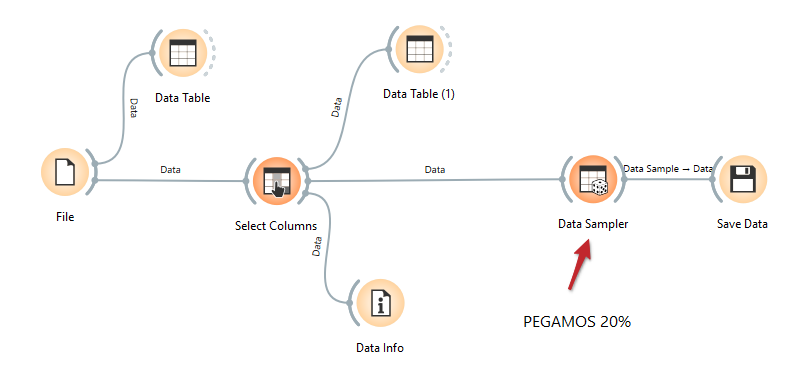

## Etapa B — Python e Pandas

### 1. Carregamento, seleção e renomeação

In [ ]:
df4 = pd.read_csv('/content/Plant_2_Generation_Data 1.csv')

colunas_df4 = ['DATE_TIME', 'SOURCE_KEY', 'DC_POWER', 'AC_POWER', 'DAILY_YIELD', 'TOTAL_YIELD']
df4 = df4[colunas_df4].copy()

df4.rename(columns={
    'DC_POWER': 'Potencia_CC',
    'AC_POWER': 'Potencia_CA',
    'DAILY_YIELD': 'Geracao_Diaria',
    'TOTAL_YIELD': 'Geracao_Total'
}, inplace=True)

display(df4.head())

,DATE_TIME,SOURCE_KEY,Potencia_CC,Potencia_CA,Geracao_Diaria,Geracao_Total
0,2020-05-28 10:00:00,vOuJvMaM2sgwLmb,1090.24,1063.56,2079.21,2307960.00
1,2020-06-16 11:15:00,81aHJ1q11NBPMrL,740.61,724.83,2209.60,1215480000.00
2,2020-05-17 18:45:00,Qf4GUc1pJu5T6c6,0.00,0.00,7220.00,838443000.00
3,2020-05-21 23:00:00,q49J1IKaHRwDQnt,0.00,0.00,4844.00,374171.00
4,2020-06-05 23:15:00,vOuJvMaM2sgwLmb,0.00,0.00,3421.00,2356530.00


### 2. Inspeção inicial

In [ ]:
print(f'Quantidade de linhas: {df4.shape[0]}')
print(f'Quantidade de colunas: {df4.shape[1]}')
print('\nEstrutura do DataFrame:')
df4.info()

print('\nEstatísticas descritivas:')
display(df4.describe(include='all').T)

print('\nValores ausentes por coluna:')
display(df4.isnull().sum().to_frame('Valores ausentes'))

print(f'Quantidade de registros com potência CA igual a zero: {(df4["Potencia_CA"] == 0).sum()}')
print(f'Potência CA mínima: {df4["Potencia_CA"].min():.2f}')
print(f'Potência CA máxima: {df4["Potencia_CA"].max():.2f}')

Quantidade de linhas: 13540
Quantidade de colunas: 6

Estrutura do DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13540 entries, 0 to 13539
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   DATE_TIME       13540 non-null  object 
 1   SOURCE_KEY      13540 non-null  object 
 2   Potencia_CC     13540 non-null  float64
 3   Potencia_CA     13540 non-null  float64
 4   Geracao_Diaria  13540 non-null  float64
 5   Geracao_Total   13540 non-null  float64
dtypes: float64(4), object(2)
memory usage: 634.8+ KB

Estatísticas descritivas:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
DATE_TIME,13540,3227,2020-05-26 17:15:00,11,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SOURCE_KEY,13540,22,WcxssY2VbP4hApt,691,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Potencia_CC,13540.00,NaN,NaN,NaN,244.93,369.46,0.00,0.00,0.00,444.31,1401.31
Potencia_CA,13540.00,NaN,NaN,NaN,239.55,361.03,0.00,0.00,0.00,435.80,1366.26
Geracao_Diaria,13540.00,NaN,NaN,NaN,3307.10,2932.39,0.00,271.72,2930.23,5556.00,9873.00
Geracao_Total,13540.00,NaN,NaN,NaN,647827396.18,720682550.38,0.00,19966300.00,282616000.00,1348470000.00,2247920000.00



Valores ausentes por coluna:


,Valores ausentes
DATE_TIME,0
SOURCE_KEY,0
Potencia_CC,0
Potencia_CA,0
Geracao_Diaria,0
Geracao_Total,0


Quantidade de registros com potência CA igual a zero: 7177
Potência CA mínima: 0.00
Potência CA máxima: 1366.26


### 3. Potência CA acima de 70% do máximo

In [ ]:
maximo_df4 = df4['Potencia_CA'].max()
limiar_df4 = maximo_df4 * 0.70
alta_geracao_df4 = df4[df4['Potencia_CA'] > limiar_df4].copy()

quantidade_alta_df4 = len(alta_geracao_df4)
percentual_alta_df4 = quantidade_alta_df4 / len(df4) * 100

print(f'Maior potência CA registrada: {maximo_df4:.2f}')
print(f'Limiar de 70%: {limiar_df4:.2f}')
print(f'Registros acima do limiar: {quantidade_alta_df4}')
print(f'Percentual da amostra: {percentual_alta_df4:.2f}%')

display(alta_geracao_df4.head(10))

Maior potência CA registrada: 1366.26
Limiar de 70%: 956.38
Registros acima do limiar: 1019
Percentual da amostra: 7.53%


,DATE_TIME,SOURCE_KEY,Potencia_CC,Potencia_CA,Geracao_Diaria,Geracao_Total
0,2020-05-28 10:00:00,vOuJvMaM2sgwLmb,1090.24,1063.56,2079.21,2307960.00
28,2020-05-25 13:15:00,V94E5Ben1TlhnDV,1214.84,1184.46,5807.29,1412160000.00
36,2020-05-25 12:15:00,WcxssY2VbP4hApt,1293.09,1260.78,4649.40,181780000.00
40,2020-05-29 12:30:00,Qf4GUc1pJu5T6c6,995.82,973.70,4488.86,838532000.00
59,2020-05-18 14:45:00,IQ2d7wF4YD8zU1Q,996.42,974.31,6351.07,19972700.00
60,2020-05-31 09:30:00,oZZkBaNadn6DNKz,980.90,959.19,1026.27,1708190000.00
68,2020-05-29 09:30:00,xoJJ8DcxJEcupym,1044.49,1021.04,1396.93,209224000.00
71,2020-05-16 10:30:00,V94E5Ben1TlhnDV,1155.32,1127.18,2593.07,1412100000.00
91,2020-05-24 09:45:00,9kRcWv60rDACzjR,1003.14,980.83,1750.47,2247780000.00
93,2020-05-28 11:15:00,q49J1IKaHRwDQnt,1210.84,1180.57,3449.00,418372.00


### 4. Frequência dos inversores nos momentos de alta geração

In [ ]:
frequencia_df4 = alta_geracao_df4['SOURCE_KEY'].value_counts()

display(frequencia_df4.to_frame('Quantidade'))

if frequencia_df4.empty:
    print('Não existem registros acima do limiar calculado.')
else:
    maior_frequencia_df4 = frequencia_df4.max()
    inversores_df4 = frequencia_df4[frequencia_df4 == maior_frequencia_df4].index.tolist()
    print(f'Inversor(es) mais frequente(s): {", ".join(map(str, inversores_df4))}')
    print(f'Quantidade de aparições: {maior_frequencia_df4}')
    print('Interpretação: a frequência mostra quais inversores aparecem mais vezes no recorte de alta geração. Esse resultado isolado não permite concluir melhor desempenho ou falha, pois seria necessário considerar tempo de operação, condições ambientais e disponibilidade de cada inversor.')

,Quantidade
SOURCE_KEY,
oZ35aAeoifZaQzV,74
Mx2yZCDsyf6DPfv,67
oZZkBaNadn6DNKz,65
Qf4GUc1pJu5T6c6,60
V94E5Ben1TlhnDV,59
4UPUqMRk7TRMgml,59
WcxssY2VbP4hApt,54
vOuJvMaM2sgwLmb,52
IQ2d7wF4YD8zU1Q,52


Inversor(es) mais frequente(s): oZ35aAeoifZaQzV
Quantidade de aparições: 74
Interpretação: a frequência mostra quais inversores aparecem mais vezes no recorte de alta geração. Esse resultado isolado não permite concluir melhor desempenho ou falha, pois seria necessário considerar tempo de operação, condições ambientais e disponibilidade de cada inversor.


### 5. Gráfico dos inversores mais frequentes

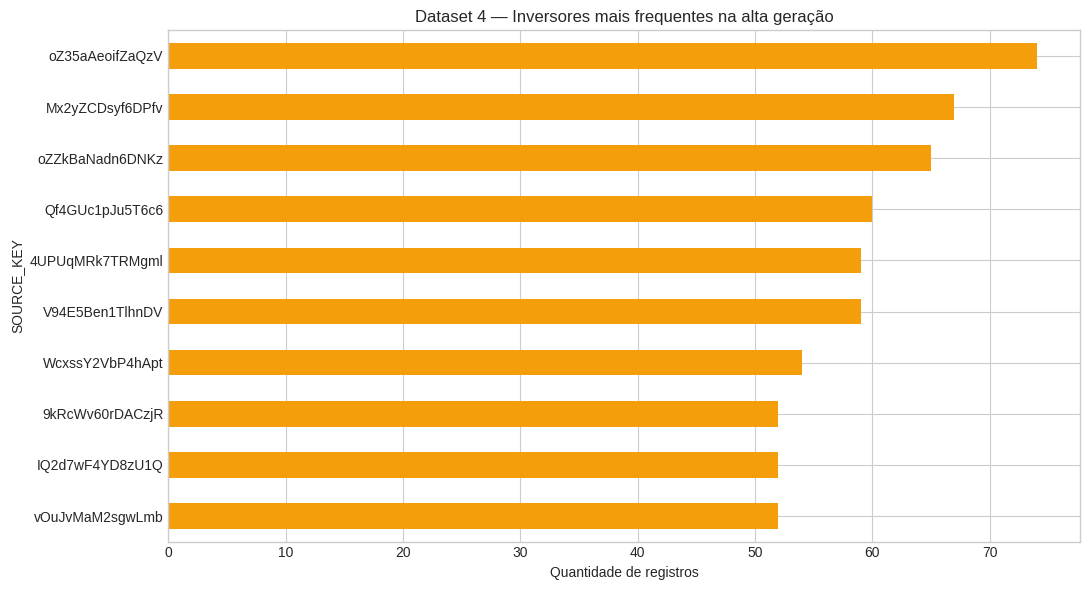

In [ ]:
plt.figure(figsize=(11, 6))
frequencia_df4.head(10).sort_values().plot(kind='barh', color='#F59E0B')
plt.title('Dataset 4 — Inversores mais frequentes na alta geração')
plt.xlabel('Quantidade de registros')
plt.ylabel('SOURCE_KEY')
plt.tight_layout()
plt.show()

# Dataset 5 — Wind & Solar Energy Production (Kaggle)

## Situação

Um operador deseja comparar a ocorrência de períodos de alta produção solar e alta produção eólica. Cada fonte deve ser comparada com o seu próprio valor máximo, pois as escalas podem ser diferentes.

## Etapa A — Orange Data Mining

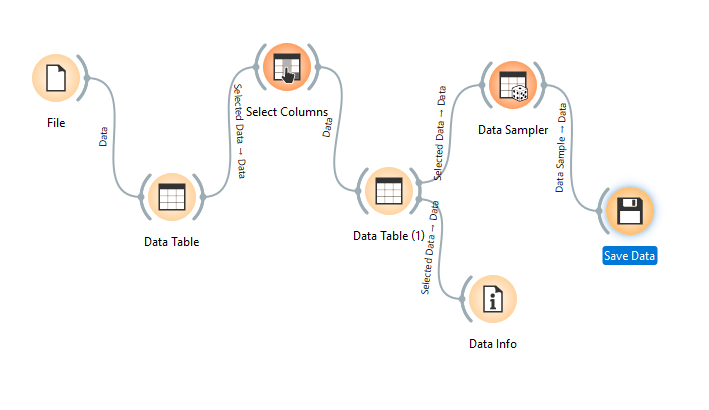

## Etapa B — Python e Pandas

### 1. Carregamento da amostra

Como os nomes originais das colunas podem variar conforme a versão do dataset, o código identifica automaticamente nomes que contenham referências a solar e a wind/eólica. As colunas identificadas são apresentadas antes da análise.

In [ ]:
df5 = pd.read_csv('/content/Energy_Production_2.csv')

display(df5.head())
print('Colunas disponíveis:')
print(df5.columns.tolist())

,Source,Season,Production
0,Solar Wind,Fall Spring Summer Winter,continuous
1,NaN,NaN,NaN
2,Wind,Spring,6587
3,Wind,Winter,11722
4,Wind,Spring,8419


Colunas disponíveis:
['Source', 'Season', 'Production']


### 2. Identificação e renomeação das variáveis de geração

In [ ]:
linhas_antes_df5 = len(df5)

df5['Source'] = df5['Source'].astype(str).str.strip().str.title()
df5['Season'] = df5['Season'].astype(str).str.strip().str.title()
df5['Production'] = pd.to_numeric(df5['Production'], errors='coerce')

df5 = df5[
    df5['Source'].isin(['Solar', 'Wind']) &
    df5['Production'].notna()
].copy()

df5.reset_index(drop=True, inplace=True)

linhas_removidas_df5 = linhas_antes_df5 - len(df5)

print(f'Linhas inválidas removidas: {linhas_removidas_df5}')
print(df5['Source'].value_counts())

solar_df5 = df5[
    df5['Source'] == 'Solar'
][['Season', 'Production']].copy()

solar_df5.rename(
    columns={'Production': 'Geracao_Solar'},
    inplace=True
)

eolica_df5 = df5[
    df5['Source'] == 'Wind'
][['Season', 'Production']].copy()

eolica_df5.rename(
    columns={'Production': 'Geracao_Eolica'},
    inplace=True
)

print('Registros solares:')
display(solar_df5.head())

print('Registros eólicos:')
display(eolica_df5.head())

Linhas inválidas removidas: 2
Source
Wind     1278
Solar     278
Name: count, dtype: int64
Registros solares:


,Season,Geracao_Solar
20,Spring,10869.00
27,Fall,3129.00
49,Summer,8561.00
50,Summer,7995.00
53,Summer,4553.00


Registros eólicos:


,Season,Geracao_Eolica
0,Spring,6587.00
1,Winter,11722.00
2,Spring,8419.00
3,Fall,15308.00
4,Spring,3028.00


### 3. Inspeção inicial

In [ ]:
print(f'Quantidade de linhas: {df5.shape[0]}')
print(f'Quantidade de colunas: {df5.shape[1]}')

df5.info()

print('Estatísticas descritivas:')
display(df5.groupby('Source')['Production'].describe())

print('Valores ausentes:')
display(df5.isnull().sum().to_frame('Valores ausentes'))

print('Registros por estação e fonte:')
display(pd.crosstab(df5['Season'], df5['Source']))

Quantidade de linhas: 1556
Quantidade de colunas: 3
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1556 entries, 0 to 1555
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Source      1556 non-null   object 
 1   Season      1556 non-null   object 
 2   Production  1556 non-null   float64
dtypes: float64(1), object(2)
memory usage: 36.6+ KB
Estatísticas descritivas:


,count,mean,std,min,25%,50%,75%,max
Source,,,,,,,,
Solar,278.00,5743.18,2364.08,1404.00,4023.25,5418.50,7371.50,16316.00
Wind,1278.00,6196.27,4180.37,185.00,2982.75,5084.50,8577.00,20075.00


Valores ausentes:


,Valores ausentes
Source,0
Season,0
Production,0


Registros por estação e fonte:


Source,Solar,Wind
Season,,
Fall,59,314
Spring,67,339
Summer,121,272
Winter,31,353


### 4. Máximos e limiares próprios de cada fonte

In [ ]:
maximo_solar_df5 = solar_df5['Geracao_Solar'].max()
maximo_eolico_df5 = eolica_df5['Geracao_Eolica'].max()

limiar_solar_df5 = maximo_solar_df5 * 0.70
limiar_eolico_df5 = maximo_eolico_df5 * 0.70

print(f'Máximo solar: {maximo_solar_df5:.2f}')
print(f'Limiar solar de 70%: {limiar_solar_df5:.2f}')

print(f'Máximo eólico: {maximo_eolico_df5:.2f}')
print(f'Limiar eólico de 70%: {limiar_eolico_df5:.2f}')

Máximo solar: 16316.00
Limiar solar de 70%: 11421.20
Máximo eólico: 20075.00
Limiar eólico de 70%: 14052.50


### 5. Registros de alta geração solar e eólica

In [ ]:
alta_solar_df5 = solar_df5[
    solar_df5['Geracao_Solar'] > limiar_solar_df5
].copy()

alta_eolica_df5 = eolica_df5[
    eolica_df5['Geracao_Eolica'] > limiar_eolico_df5
].copy()

quantidade_solar_df5 = len(alta_solar_df5)
quantidade_eolica_df5 = len(alta_eolica_df5)

percentual_solar_df5 = (
    quantidade_solar_df5 / len(solar_df5) * 100
)

percentual_eolica_df5 = (
    quantidade_eolica_df5 / len(eolica_df5) * 100
)

print(
    f'Alta geração solar: {quantidade_solar_df5} registros '
    f'({percentual_solar_df5:.2f}%)'
)

print(
    f'Alta geração eólica: {quantidade_eolica_df5} registros '
    f'({percentual_eolica_df5:.2f}%)'
)

display(alta_solar_df5.head())
display(alta_eolica_df5.head())

Alta geração solar: 6 registros (2.16%)
Alta geração eólica: 81 registros (6.34%)


,Season,Geracao_Solar
252,Fall,11438.00
455,Summer,16316.00
723,Summer,11543.00
818,Summer,12313.00
980,Fall,12354.00


,Season,Geracao_Eolica
3,Fall,15308.00
19,Winter,17057.00
40,Spring,18551.00
47,Winter,18217.00
73,Winter,14424.00


### 6. Gráfico comparativo

In [ ]:
if percentual_solar_df5 > percentual_eolica_df5:
    fonte_frequente_df5 = 'solar'
    diferenca_df5 = percentual_solar_df5 - percentual_eolica_df5

elif percentual_eolica_df5 > percentual_solar_df5:
    fonte_frequente_df5 = 'eólica'
    diferenca_df5 = percentual_eolica_df5 - percentual_solar_df5

else:
    fonte_frequente_df5 = 'solar e eólica igualmente'
    diferenca_df5 = 0

print(
    f'A geração {fonte_frequente_df5} aparece com maior frequência '
    f'acima de 70% do próprio máximo.'
)

print(
    f'Diferença entre os percentuais: '
    f'{diferenca_df5:.2f} ponto(s) percentual(is).'
)

print(
    'Não seria adequado usar o mesmo limite numérico para as duas '
    'fontes, pois a produção solar e a produção eólica possuem '
    'escalas diferentes.'
)

A geração eólica aparece com maior frequência acima de 70% do próprio máximo.
Diferença entre os percentuais: 4.18 ponto(s) percentual(is).
Não seria adequado usar o mesmo limite numérico para as duas fontes, pois a produção solar e a produção eólica possuem escalas diferentes.


# Dataset 6 — Individual Household Electric Power Consumption (UCI)

## Situação

Uma residência deseja identificar episódios de potência ativa elevada que também apresentem corrente acima do comportamento médio.

## Etapa A — Orange Data Mining

O fluxo correto deve partir do dataset original, inspecionar os ausentes, realizar o tratamento conforme a aula, manter `Global_active_power`, `Global_reactive_power`, `Voltage`, `Global_intensity` e os três `Sub_metering`, gerar uma nova amostra aleatória de 10% e exportá-la em CSV.

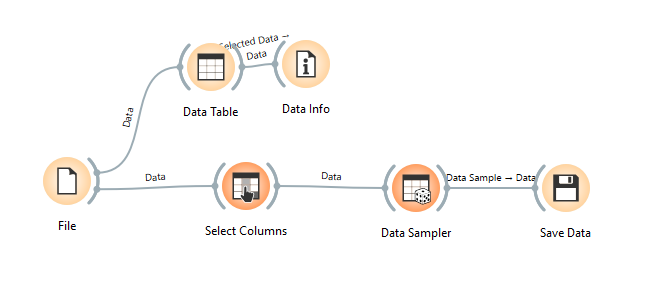

## Etapa B — Python e Pandas

### 1. Carregamento, seleção e conversão das variáveis

A conversão com `errors='coerce'` transforma valores não numéricos, como `?`, em ausentes. O notebook informa quantos ausentes existiam e remove apenas linhas incompletas nas variáveis necessárias para a análise.

In [ ]:
df6 = pd.read_csv('/content/individual_household 1.csv')

colunas_df6 = [
    'Global_active_power',
    'Global_reactive_power',
    'Voltage',
    'Global_intensity',
    'Sub_metering_1',
    'Sub_metering_2',
    'Sub_metering_3'
]
df6 = df6[colunas_df6].copy()

for coluna in colunas_df6:
    df6[coluna] = pd.to_numeric(df6[coluna], errors='coerce')

print('Valores ausentes antes do tratamento:')
display(df6.isnull().sum().to_frame('Valores ausentes'))

linhas_antes_df6 = len(df6)
df6.dropna(subset=colunas_df6, inplace=True)
df6.reset_index(drop=True, inplace=True)
linhas_removidas_df6 = linhas_antes_df6 - len(df6)

print(f'Linhas removidas no tratamento: {linhas_removidas_df6}')

Valores ausentes antes do tratamento:


,Valores ausentes
Global_active_power,0
Global_reactive_power,0
Voltage,0
Global_intensity,0
Sub_metering_1,0
Sub_metering_2,0
Sub_metering_3,0


Linhas removidas no tratamento: 0


### 2. Renomeação e inspeção inicial

In [ ]:
df6.rename(columns={
    'Global_active_power': 'Potencia_Ativa',
    'Global_reactive_power': 'Potencia_Reativa',
    'Voltage': 'Tensao',
    'Global_intensity': 'Corrente',
    'Sub_metering_1': 'Medidor_1',
    'Sub_metering_2': 'Medidor_2',
    'Sub_metering_3': 'Medidor_3'
}, inplace=True)

display(df6.head())
print(f'Quantidade de linhas: {df6.shape[0]}')
print(f'Quantidade de colunas: {df6.shape[1]}')
print('\nEstrutura do DataFrame:')
df6.info()

print('\nEstatísticas descritivas:')
display(df6.describe().T)

,Potencia_Ativa,Potencia_Reativa,Tensao,Corrente,Medidor_1,Medidor_2,Medidor_3
0,0.32,0.23,239.22,1.60,0,1,1
1,1.57,0.18,244.15,6.40,0,0,18
2,0.24,0.09,239.33,1.00,0,0,0
3,0.19,0.14,237.71,1.00,0,0,1
4,1.79,0.39,235.89,7.60,0,1,17


Quantidade de linhas: 20493
Quantidade de colunas: 7

Estrutura do DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20493 entries, 0 to 20492
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Potencia_Ativa    20493 non-null  float64
 1   Potencia_Reativa  20493 non-null  float64
 2   Tensao            20493 non-null  float64
 3   Corrente          20493 non-null  float64
 4   Medidor_1         20493 non-null  int64  
 5   Medidor_2         20493 non-null  int64  
 6   Medidor_3         20493 non-null  int64  
dtypes: float64(4), int64(3)
memory usage: 1.1 MB

Estatísticas descritivas:


,count,mean,std,min,25%,50%,75%,max
Potencia_Ativa,20493.00,1.09,1.05,0.08,0.31,0.59,1.53,9.12
Potencia_Reativa,20493.00,0.12,0.11,0.00,0.05,0.10,0.20,0.97
Tensao,20493.00,240.84,3.23,225.81,239.00,241.01,242.86,253.32
Corrente,20493.00,4.61,4.43,0.20,1.40,2.60,6.40,39.40
Medidor_1,20493.00,1.11,6.13,0.00,0.00,0.00,0.00,83.00
Medidor_2,20493.00,1.31,5.87,0.00,0.00,0.00,1.00,78.00
Medidor_3,20493.00,6.47,8.47,0.00,0.00,1.00,17.00,31.00


### 3. Potência ativa acima de 75% do máximo

In [ ]:
maximo_df6 = df6['Potencia_Ativa'].max()
limiar_df6 = maximo_df6 * 0.75
potencia_alta_df6 = df6[df6['Potencia_Ativa'] > limiar_df6].copy()

quantidade_alta_df6 = len(potencia_alta_df6)
percentual_alta_df6 = quantidade_alta_df6 / len(df6) * 100

print(f'Potência ativa máxima: {maximo_df6:.3f}')
print(f'Limiar de 75%: {limiar_df6:.3f}')
print(f'Registros acima do limiar: {quantidade_alta_df6}')
print(f'Percentual da amostra: {percentual_alta_df6:.2f}%')

display(potencia_alta_df6.head(10))

Potência ativa máxima: 9.118
Limiar de 75%: 6.838
Registros acima do limiar: 23
Percentual da amostra: 0.11%


,Potencia_Ativa,Potencia_Reativa,Tensao,Corrente,Medidor_1,Medidor_2,Medidor_3
415,7.88,0.09,233.98,33.60,36,72,17
558,7.12,0.34,231.54,31.00,0,63,17
1414,6.84,0.05,237.20,28.80,0,0,0
1469,7.97,0.34,231.55,34.40,77,0,17
2405,7.00,0.08,234.06,29.80,0,71,17
3239,6.84,0.23,228.95,30.20,4,0,17
3796,7.63,0.54,229.37,33.20,36,33,17
4461,8.28,0.09,231.50,35.60,0,71,17
4820,7.24,0.11,243.41,29.80,0,73,18
5550,7.44,0.15,235.59,31.60,0,1,17


### 4. Inclusão da corrente acima da média

In [ ]:
corrente_media_df6 = df6['Corrente'].mean()
potencia_corrente_df6 = potencia_alta_df6[
    potencia_alta_df6['Corrente'] > corrente_media_df6
].copy()

quantidade_duplo_df6 = len(potencia_corrente_df6)
removidos_df6 = quantidade_alta_df6 - quantidade_duplo_df6
reducao_df6 = removidos_df6 / quantidade_alta_df6 * 100 if quantidade_alta_df6 else 0

print(f'Corrente média: {corrente_media_df6:.3f}')
print(f'Somente potência elevada: {quantidade_alta_df6}')
print(f'Potência elevada e corrente acima da média: {quantidade_duplo_df6}')
print(f'Registros removidos: {removidos_df6}')
print(f'Redução relativa: {reducao_df6:.2f}%')
print(f'Interpretação: a corrente como segunda condição reduziu o conjunto de {quantidade_alta_df6} para {quantidade_duplo_df6} registros. O novo recorte destaca episódios mais específicos de elevada demanda elétrica.')

display(potencia_corrente_df6.head(10))

Corrente média: 4.607
Somente potência elevada: 23
Potência elevada e corrente acima da média: 23
Registros removidos: 0
Redução relativa: 0.00%
Interpretação: a corrente como segunda condição reduziu o conjunto de 23 para 23 registros. O novo recorte destaca episódios mais específicos de elevada demanda elétrica.


,Potencia_Ativa,Potencia_Reativa,Tensao,Corrente,Medidor_1,Medidor_2,Medidor_3
415,7.88,0.09,233.98,33.60,36,72,17
558,7.12,0.34,231.54,31.00,0,63,17
1414,6.84,0.05,237.20,28.80,0,0,0
1469,7.97,0.34,231.55,34.40,77,0,17
2405,7.00,0.08,234.06,29.80,0,71,17
3239,6.84,0.23,228.95,30.20,4,0,17
3796,7.63,0.54,229.37,33.20,36,33,17
4461,8.28,0.09,231.50,35.60,0,71,17
4820,7.24,0.11,243.41,29.80,0,73,18
5550,7.44,0.15,235.59,31.60,0,1,17


### 5. Gráfico de potência ativa e corrente

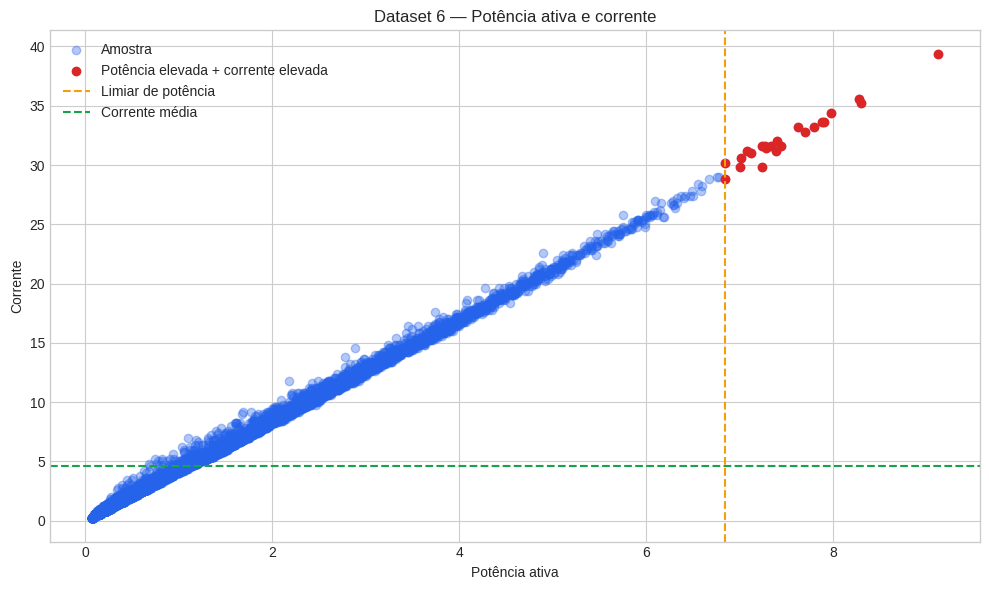

In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(df6['Potencia_Ativa'], df6['Corrente'], alpha=0.35, color='#2563EB', label='Amostra')
plt.scatter(
    potencia_corrente_df6['Potencia_Ativa'],
    potencia_corrente_df6['Corrente'],
    color='#DC2626',
    label='Potência elevada + corrente elevada'
)
plt.axvline(limiar_df6, color='#F59E0B', linestyle='--', label='Limiar de potência')
plt.axhline(corrente_media_df6, color='#16A34A', linestyle='--', label='Corrente média')
plt.title('Dataset 6 — Potência ativa e corrente')
plt.xlabel('Potência ativa')
plt.ylabel('Corrente')
plt.legend()
plt.tight_layout()
plt.show()

# Conclusão geral

Os seis exercícios utilizam limites proporcionais aos próprios dados para identificar eventos de maior consumo ou geração. A inclusão de uma segunda condição torna os recortes mais específicos, mas as conclusões devem sempre ser interpretadas no contexto de cada dataset e sem extrapolar o que os dados analisados conseguem demonstrar.